### 1. you have to create one supervisor node.

In [2]:
import os
from dotenv import load_dotenv
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")


### Config the model

In [3]:
from langchain_google_genai import ChatGoogleGenerativeAI

In [ ]:
model = ChatGoogleGenerativeAI(model='gemini-1.5-flash',google_api_key = "")
output= model.invoke("hi i am dj")
print(output.content)

Hi DJ!  What's up?


### Config the embedding model

In [5]:
from langchain_huggingface import HuggingFaceEmbeddings

In [6]:
embeddings = HuggingFaceEmbeddings(model_name="BAAI/bge-small-en")

d:\Agentic AI\Venv Project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
len(embeddings.embed_query("Hi dj"))

384

### Dataingestion(Load Data)


In [8]:
from langchain_community.document_loaders import PyPDFLoader, DirectoryLoader

In [9]:
loader=DirectoryLoader("../Assignments",glob="./testpdf.pdf",loader_cls=PyPDFLoader)

In [10]:
docs=loader.load()
docs

[Document(metadata={'producer': 'GPL Ghostscript 9.27', 'creator': 'PDF24 Creator', 'creationdate': '2022-07-31T13:15:05+02:00', 'moddate': '2022-07-31T13:15:27+02:00', 'pxcviewerinfo': "PDF-XChange Viewer;2.5.214.2;Feb 17 2014;20:31:41;D:20220731131527+02'00'", 'source': '..\\Assignments\\testpdf.pdf', 'total_pages': 251, 'page': 0, 'page_label': '1'}, page_content='Killing Floor \n \nJack Reacher,  #1  \n \n \nby Lee Child, 1954– \n \n \nPublished:  1997 \n \n \n \n \n \nJ J J J J   I I I I I \n \n \n \n \n \nTable of Contents \n \n \nChapter  1 …  thru  …  Chapter  34 \n \n \n \nJ J J J J   I I I I I'),
 Document(metadata={'producer': 'GPL Ghostscript 9.27', 'creator': 'PDF24 Creator', 'creationdate': '2022-07-31T13:15:05+02:00', 'moddate': '2022-07-31T13:15:27+02:00', 'pxcviewerinfo': "PDF-XChange Viewer;2.5.214.2;Feb 17 2014;20:31:41;D:20220731131527+02'00'", 'source': '..\\Assignments\\testpdf.pdf', 'total_pages': 251, 'page': 1, 'page_label': '2'}, page_content="Chapter  1 \n \n

In [11]:
docs[0].page_content

'Killing Floor \n \nJack Reacher,  #1  \n \n \nby Lee Child, 1954– \n \n \nPublished:  1997 \n \n \n \n \n \nJ J J J J   I I I I I \n \n \n \n \n \nTable of Contents \n \n \nChapter  1 …  thru  …  Chapter  34 \n \n \n \nJ J J J J   I I I I I'

### Split Data in Chunks

In [12]:
from langchain.text_splitter import RecursiveCharacterTextSplitter

In [13]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 500,
    chunk_overlap = 50
)

In [14]:
new_docs = text_splitter.split_documents(documents=docs)
new_docs

[Document(metadata={'producer': 'GPL Ghostscript 9.27', 'creator': 'PDF24 Creator', 'creationdate': '2022-07-31T13:15:05+02:00', 'moddate': '2022-07-31T13:15:27+02:00', 'pxcviewerinfo': "PDF-XChange Viewer;2.5.214.2;Feb 17 2014;20:31:41;D:20220731131527+02'00'", 'source': '..\\Assignments\\testpdf.pdf', 'total_pages': 251, 'page': 0, 'page_label': '1'}, page_content='Killing Floor \n \nJack Reacher,  #1  \n \n \nby Lee Child, 1954– \n \n \nPublished:  1997 \n \n \n \n \n \nJ J J J J   I I I I I \n \n \n \n \n \nTable of Contents \n \n \nChapter  1 …  thru  …  Chapter  34 \n \n \n \nJ J J J J   I I I I I'),
 Document(metadata={'producer': 'GPL Ghostscript 9.27', 'creator': 'PDF24 Creator', 'creationdate': '2022-07-31T13:15:05+02:00', 'moddate': '2022-07-31T13:15:27+02:00', 'pxcviewerinfo': "PDF-XChange Viewer;2.5.214.2;Feb 17 2014;20:31:41;D:20220731131527+02'00'", 'source': '..\\Assignments\\testpdf.pdf', 'total_pages': 251, 'page': 1, 'page_label': '2'}, page_content="Chapter  1 \n \n

In [15]:
doc_string = [doc.page_content for doc in new_docs]
doc_string

['Killing Floor \n \nJack Reacher,  #1  \n \n \nby Lee Child, 1954– \n \n \nPublished:  1997 \n \n \n \n \n \nJ J J J J   I I I I I \n \n \n \n \n \nTable of Contents \n \n \nChapter  1 …  thru  …  Chapter  34 \n \n \n \nJ J J J J   I I I I I',
 "Chapter  1 \n \n \n  I was arrested in Eno's diner. At twelve o'clock.  I was eating eggs and drinking \ncoffee. A late breakfast, not lunch. I was wet and tired after a long walk in heavy \nrain.  \n  All the way from the highway to the edge of town.   \n  The diner was small, but bright and clean. Brand- new, built to resemble a \nconverted railroad car.  \n  Narrow, with a long lunch counter on one side and  a kitchen bumped out back.",
 "Booths lining the opposite wall. A doorway where the centre booth would be.  \n  I was in a booth, at a window, reading somebody's  abandoned newspaper about \nthe campaign for a President I didn't vote for last  time and wasn't going to vote for \nthis time. Outside, the rain had stopped but the glass was

In [16]:
len(doc_string)

1822

### Embeddings

In [17]:
from langchain_community.vectorstores import Chroma

In [18]:
db=Chroma.from_documents(new_docs,embeddings)

### as_retriever (User Side)

In [19]:
retriever = db.as_retriever()

In [20]:
retriever.invoke("where Eno's arrested?")

[Document(metadata={'total_pages': 251, 'page_label': '2', 'creator': 'PDF24 Creator', 'moddate': '2022-07-31T13:15:27+02:00', 'source': '..\\Assignments\\testpdf.pdf', 'page': 1, 'creationdate': '2022-07-31T13:15:05+02:00', 'producer': 'GPL Ghostscript 9.27', 'pxcviewerinfo': "PDF-XChange Viewer;2.5.214.2;Feb 17 2014;20:31:41;D:20220731131527+02'00'"}, page_content="Chapter  1 \n \n \n  I was arrested in Eno's diner. At twelve o'clock.  I was eating eggs and drinking \ncoffee. A late breakfast, not lunch. I was wet and tired after a long walk in heavy \nrain.  \n  All the way from the highway to the edge of town.   \n  The diner was small, but bright and clean. Brand- new, built to resemble a \nconverted railroad car.  \n  Narrow, with a long lunch counter on one side and  a kitchen bumped out back."),
 Document(metadata={'page_label': '58', 'creator': 'PDF24 Creator', 'pxcviewerinfo': "PDF-XChange Viewer;2.5.214.2;Feb 17 2014;20:31:41;D:20220731131527+02'00'", 'producer': 'GPL Ghosts

## creation of pydantic class

In [21]:
from pydantic import BaseModel,Field


In [22]:
class TopicSelectionParser(BaseModel):
    Topic:str=Field(description="selected topic")
    Reasoning:str=Field(description='Reasoning behind topic selection')

In [23]:
from langchain.output_parsers import PydanticOutputParser

In [24]:
parser = PydanticOutputParser(pydantic_object=TopicSelectionParser)

In [25]:
parser.get_format_instructions()

'The output should be formatted as a JSON instance that conforms to the JSON schema below.\n\nAs an example, for the schema {"properties": {"foo": {"title": "Foo", "description": "a list of strings", "type": "array", "items": {"type": "string"}}}, "required": ["foo"]}\nthe object {"foo": ["bar", "baz"]} is a well-formatted instance of the schema. The object {"properties": {"foo": ["bar", "baz"]}} is not well-formatted.\n\nHere is the output schema:\n```\n{"properties": {"Topic": {"description": "selected topic", "title": "Topic", "type": "string"}, "Reasoning": {"description": "Reasoning behind topic selection", "title": "Reasoning", "type": "string"}}, "required": ["Topic", "Reasoning"]}\n```'

# this agentstate class you need to inside the stategraph

In [29]:
import operator
from typing import TypedDict, Annotated, Sequence
from langchain_core.messages import BaseMessage

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]

# 1. Supervisor Node


In [38]:
from langchain.prompts import PromptTemplate

def supervisor_node(state:AgentState):
    print(f"Supervisor Node {state}")
    question=state["messages"][-1]
    print("Question",question)
    
    template = """
    You are a supervisor AI tasked with routing user queries to the correct module. You must classify each query into one of the following categories based on its requirement:

    - "LLM" if it is a general, creative, or conversational question not needing external data.
    - "RAG" if the query specifically relates to **India's performance or participation in the Summer Olympics** and should be answered using a Retrieval-Augmented Generation system.
    - "WEB" if the question requires real-time or up-to-date information from the internet.

    Strictly Only respond with one of the category names: LLM, RAG, or WEB.

    User query: {question}
    {format_instructions}
    """
    
    prompt= PromptTemplate(
        template=template,
        input_variable=["question"],
        partial_variables={"format_instructions": parser.get_format_instructions()}
    )
    
    chain= prompt | model | parser
    
    response = chain.invoke({"question":question})
    
    print("Parsed response:", response)
    
    return {"messages": [response.Topic]}
    

In [ ]:
state={"messages":["Hi"]}

supervisor_node(state)

Supervisor Node {'messages': ['Current president of India']}
Question Current president of India
Parsed response: Topic='WEB' Reasoning='The current president of India requires up-to-date information best obtained from a real-time web search.'


{'messages': ['WEB']}

# 2. router function

In [46]:

def router(state:AgentState):
    print(f"-> ROUTER -> {state}")
    
    topic=state["messages"][-1]
    print(f"topic recieved from supervisor node: {topic}")
    
    if "WEB" in topic.upper():
        return "WEB call"
    elif "RAG" in topic.upper():
        return "RAG call"
    else:
        return "LLM call"

# 3. LLM function

In [47]:
def llm_method(state:AgentState):
    print(f"-->LLM Call --> {state}")
    question = state["messages"][0]
    question_with_prompt = "Answer the follow question with you knowledge of the real world. Following is the user question: "+ question
    response = model.invoke(question_with_prompt)
    return{"messages":[response.content]}
          

# 4.RAG Function

In [48]:
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

In [49]:
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

def rag_method(state:AgentState):
    print(f"---->RAG CALL--->{state}")
    
    question = state["messages"][0]
    
    prompt=PromptTemplate(
        template="""You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.\nQuestion: {question} \nContext: {context} \nAnswer:""",
        
        input_variables=['context', 'question']
    )
    
    rag_chain = (
        {"context": retriever | format_docs, "question" : RunnablePassthrough()}
        | prompt
        | model
        | StrOutputParser()
    )
    
    result = rag_chain.invoke(question)
    return {"message": [result]}

# 5. WEB Function

In [54]:
from langchain_community.tools import DuckDuckGoSearchRun

search = DuckDuckGoSearchRun(return_direct=True)
search.invoke("sachin")


"Sachin Ramesh Tendulkar (/ ˌ s ʌ tʃ ɪ n t ɛ n ˈ d uː l k ər / ⓘ; Marathi: [sətɕin t̪eɳɖulkəɾ]; born 24 April 1973) is an Indian former international cricketer who captained the Indian national team. Sachin Tendulkar, cricketing maestro and former member of India's Rajya Sabha, enthralled fans worldwide with his talent and record-breaking career that earned him the title God of Cricket. He is the leading run scorer in both Test cricket and one-day internationals (ODIs) and the first cricketer to score 100 centuries (100 runs in a single innings) in international cricket. Sachin has been lauded with Arjuna Award in 1994, Khel Ratna in 1997, Padma Shri in 1998 and Padma Vibhushan (2008) honours. He is the only sportsperson to be conferred the Bharat Ratna in 2013. Sachin Tendulkar retired in 2012 at his home ground of Wankhede Stadium in Mumbai. Learn about Sachin Tendulkar, the legendary Indian cricketer who holds many world records and received numerous honours and awards. Find out his

In [72]:
def web_node(state:AgentState):
    print(f"--->WEB NODE--->{state}")
    query = state["messages"][0]
    response = search.invoke(query)
    print(f"Web crawler result: {response}")
    return {"message":[response]}

# 6. validation Node

In [73]:
class ValidateOutput(BaseModel):
    Validation: str = Field(description="Indicate whether the response is valid or invalid.")
    Reasoning: str = Field(description="Provide the reasoning behind the validation or invalidation of the response.")
    

In [74]:
validation_parser = PydanticOutputParser(pydantic_object=ValidateOutput)

In [75]:
def validation_router(state:AgentState):
    print(f"--- Validation router ---")
    validation = state["messages"][-1]
    if "invalid" in validation.lower():
        return "invalid response"
    else:
        return "valid response"

In [76]:
def validation_node(state:AgentState):
    print("---- validation node -----")
    response=state["messages"][-1]
    question=state["messages"][0]

    print(f" Question:{question}, \n Response:{response}")

    template = template = """
    Your task is to evaluate the relevance and correctness of a response generated by an AI system (RAG, LLM, or Web Crawler) based on the original user query.

    You must:
    1. Decide whether the response correctly and sufficiently answers the user query.
    2. If yes, mark it as **Valid**.
    3. If not, mark it as **Invalid**

    Respond strictly using the required format.

    User Query: {question}
    AI Response: {response}

    {format_instructions}
    """

    prompt = PromptTemplate(
        template=template,
        input_variables=["question", "response"],
        partial_variables={"format_instructions":validation_parser.get_format_instructions()}
    )

    chain = prompt | model | validation_parser

    response = chain.invoke({"question":question, "response":response})

    print(f"response from supervisor node : {response}")

    return {"messages":[response.Validation]}

# final output

In [77]:
def final_output_node(state:AgentState):
    print(f"---- final output ----")
    print(f" Question: {state['messages'][0]} \n final Answer: {state['messages'][-1]}")

# 7. Workflow

In [78]:
from langgraph.graph import StateGraph,END

workflow = StateGraph(AgentState)

# Add nodes
workflow.add_node("Supervisor", supervisor_node)
workflow.add_node("RAG", rag_method)
workflow.add_node("LLM", llm_method)
workflow.add_node("WEB", web_node)
workflow.add_node("Validation", validation_node)
workflow.add_node("final_output", final_output_node)

# Set the entry point
workflow.set_entry_point("Supervisor")

# Add conditional edges from Supervisor to RAG/LLM/WEB
workflow.add_conditional_edges(
    "Supervisor",
    router,
    {
        "RAG call": "RAG",
        "LLM call": "LLM",
        "WEB call": "WEB"
    }
)

# Add edges from RAG/LLM/WEB to Validation
workflow.add_edge("RAG", "Validation")
workflow.add_edge("LLM", "Validation")
workflow.add_edge("WEB", "Validation")

# Add conditional edges from Validation to END or Supervisor
workflow.add_conditional_edges(
    "Validation",
    validation_router,
    {
        "invalid response": "Supervisor",
        "valid response": "final_output"
    }
)

workflow.add_edge("final_output", END)

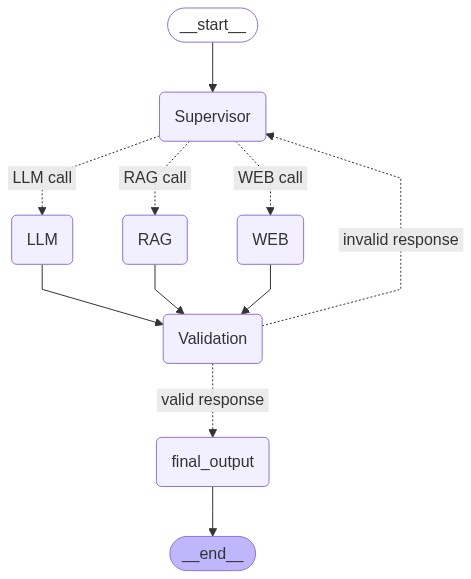

In [79]:
app=workflow.compile()
app

# Workflow testing

In [80]:
state = {"messages": ["Hello"]}
app.invoke(state)

Supervisor Node {'messages': ['Hello']}
Question Hello
Parsed response: Topic='LLM' Reasoning="The query 'Hello' is a simple greeting and does not require any specific information retrieval or external data."
-> ROUTER -> {'messages': ['Hello', 'LLM']}
topic recieved from supervisor node: LLM
-->LLM Call --> {'messages': ['Hello', 'LLM']}
---- validation node -----
 Question:Hello, 
 Response:Hello!
response from supervisor node : Validation='Valid' Reasoning="The AI response appropriately mirrors the user's greeting, providing a simple and correct answer to the query."
--- Validation router ---
---- final output ----
 Question: Hello 
 final Answer: Valid


{'messages': ['Hello', 'LLM', 'Hello!', 'Valid']}

In [81]:
state = {"messages":["Who won first olympic medal for India"]}
app.invoke(state)

Supervisor Node {'messages': ['Who won first olympic medal for India']}
Question Who won first olympic medal for India
Parsed response: Topic='RAG' Reasoning="The query asks about India's Olympic history, requiring specific historical data best retrieved from a RAG system."
-> ROUTER -> {'messages': ['Who won first olympic medal for India', 'RAG']}
topic recieved from supervisor node: RAG
---->RAG CALL--->{'messages': ['Who won first olympic medal for India', 'RAG']}
---- validation node -----
 Question:Who won first olympic medal for India, 
 Response:RAG
response from supervisor node : Validation='Invalid' Reasoning="The AI response only says 'RAG', which is not an answer to the question.  It needs to specify who won the first Olympic medal for India (Norman Pritchard)."
--- Validation router ---
Supervisor Node {'messages': ['Who won first olympic medal for India', 'RAG', 'Invalid']}
Question Invalid
Parsed response: Topic='LLM' Reasoning="The query 'Invalid' does not provide enough

{'messages': ['Who won first olympic medal for India',
  'RAG',
  'Invalid',
  'LLM',
  'The first Olympic medal for India was won by **Norman Pritchard** in the 1900 Paris Olympics.  He won two bronze medals in athletics.',
  'Valid']}

In [82]:
state = {"messages":["Who is the president of India"]}
app.invoke(state)

Supervisor Node {'messages': ['Who is the president of India']}
Question Who is the president of India
Parsed response: Topic='WEB' Reasoning='The query requires current information, best obtained from a real-time internet search.'
-> ROUTER -> {'messages': ['Who is the president of India', 'WEB']}
topic recieved from supervisor node: WEB
--->WEB NODE--->{'messages': ['Who is the president of India', 'WEB']}
Web crawler result: Learn about the 15 Presidents of India who have been elected so far, from Rajendra Prasad to Draupadi Murmu. Find out their tenure, achievements, awards and other details in this comprehensive list. Droupadi Murmu, who was born June 20, 1958, in Uparbeda, is the 15th president of India. She began her term in July 2022. Murmu is the first person from the tribal community, and the second woman after Pratibha Patil, to hold the office of president. She is also the first president to have been born in independent India as well as the youngest person to occupy the po

{'messages': ['Who is the president of India',
  'WEB',
  'Invalid',
  'LLM',
  'The current president of India is Droupadi Murmu.',
  'Valid']}